In [12]:
from langchain_groq import ChatGroq

In [13]:
llm=ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0,
)
response = llm.invoke("What is the capital of France?")

In [14]:
response.content

'<think>\n\n</think>\n\nThe capital of France is Paris.'

In [15]:
from langchain.tools import tool

Custom tools

In [16]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers.
Args:
    a (int): The first number.
    b (int): The second number.
Returns:
    int: The product of a and b.
"""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds two numbers.
    Args:
        a (int): The first number.
        b (int): The second number.
    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divides a by b.
    Args:
        a (int): The numerator.
        b (int): The denominator.
    Returns:
        float: The result of the division.
    """     
    if b == 0:
        raise ValueError("Division by zero is not allowed.")
    return a / b


In [17]:
from langchain_community.tools import DuckDuckGoSearchRun

In [18]:
search = DuckDuckGoSearchRun()

In [19]:
search.invoke("iPhone 17 release date")

c:\Swdtools\conda_envs\py311_agenticai\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


'No good DuckDuckGo Search Result was found'

In [20]:
tools = [multiply, add, divide, search]

In [21]:
llm_with_tools = llm.bind_tools(tools)

In [22]:
response = llm_with_tools.invoke("Hii")
response

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'Alright, the user sent "Hii". That\'s a friendly greeting, but not a specific question or task. I should respond in a way that\'s welcoming and offers assistance. Maybe ask how I can help them today. Keeping it open-ended encourages them to provide more details about what they need.\n'}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 388, 'total_tokens': 462, 'completion_time': 0.388440802, 'prompt_time': 0.044189185, 'queue_time': 0.046299265, 'total_time': 0.432629987}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--0b63c307-d2d9-4235-8366-1eee271d2a74-0', usage_metadata={'input_tokens': 388, 'output_tokens': 74, 'total_tokens': 462})

In [23]:
response = llm_with_tools.invoke("what is 2+2? ")
response


AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "what is 2+2?" So, I need to figure out how to respond using the tools provided. Let me look at the available functions. There\'s add, multiply, divide, and duckduckgo_search. Since the question is about addition, the add function is the right choice.\n\nThe add function takes two integers, a and b, and returns their sum. So, I should call the add function with a=2 and b=2. That should give me 4. I need to format the tool call correctly in JSON within the XML tags as specified.\n\nI should make sure the function name is "add" and the arguments are a JSON object with a and b set to 2 each. That should do it.\n', 'tool_calls': [{'id': 'ws1pbcb8t', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 189, 'prompt_tokens': 394, 'total_tokens': 583, 'completion_time': 0.777369108, 'prompt_time': 0.044784629, 'queue_time

In [24]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END,MessagesState


In [25]:
builder = StateGraph(MessagesState)

In [29]:
def function_1(state: MessagesState) -> MessagesState:
    pass

In [30]:
builder.add_node("llm_decision_step", function_1)

In [ ]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))


In [34]:
builder.add_edge(START, "llm_decision_step")

In [ ]:
from langgraph.prebuilt import tools_condition


builder.add_conditional_edges("llm_decision_step",
                              tools_condition)

In [38]:
builder.add_edge("tools", "llm_decision_step")

In [39]:
react_graph = builder.compile()

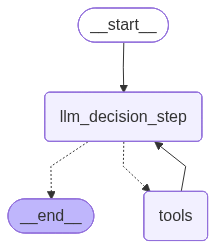

In [41]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))